In [ ]:
# 03. Incident Duration Modeling

This notebook develops predictive models for traffic incident clearance time using cleaned MDOT CHART data.

## Objectives

- Predict incident duration using regression
- Identify long-duration incidents (>60 min) using classification
- Compare model performance against simple baselines
- Interpret important predictors

## Models

- Random Forest Regressor
- Random Forest Classifier

## Output

This notebook generates model metrics, prediction diagnostics, and feature importance summaries.

In [ ]:
## 1. Configuration

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import warnings

warnings.filterwarnings("ignore")

PROJECT_ROOT = Path(r"\\\\Traffic_Incident")

INPUT_DATA = PROJECT_ROOT / "data" / "processed" / "chart_model_incident.parquet"
OUTPUT_TABLE_DIR = PROJECT_ROOT / "outputs" / "tables"
OUTPUT_FIG_DIR = PROJECT_ROOT / "outputs" / "figures"
OUTPUT_MODEL_DIR = PROJECT_ROOT / "outputs" / "models"

OUTPUT_TABLE_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_FIG_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_MODEL_DIR.mkdir(parents=True, exist_ok=True)

print("INPUT_DATA exists:", INPUT_DATA.exists())
print("OUTPUT_TABLE_DIR:", OUTPUT_TABLE_DIR)
print("OUTPUT_FIG_DIR:", OUTPUT_FIG_DIR)
print("OUTPUT_MODEL_DIR:", OUTPUT_MODEL_DIR)

INPUT_DATA exists: True
OUTPUT_TABLE_DIR: \\\\Traffic_Incident\outputs\tables
OUTPUT_FIG_DIR: \\\\Traffic_Incident\outputs\figures
OUTPUT_MODEL_DIR: \\\\Traffic_Incident\outputs\models


In [ ]:
## 2. Libraries

In [2]:
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    median_absolute_error,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix
)
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier

In [ ]:
## 3. Load Modeling Dataset

This section loads the cleaned incident dataset created in the previous notebook.

In [3]:
df = pd.read_parquet(INPUT_DATA)

print("Rows:", f"{len(df):,}")
print("Columns:", len(df.columns))
df.head()

Rows: 408,904
Columns: 38


,source_file,row_in_source,event_uid,year_inferred,agency,event_type,agency_type,agency_subtype,start_time,closed_time,...,milepost,duration_missing,duration_nonpositive,duration_gt_24hr,duration_gt_7day,is_incident_like,log_duration_min,long_duration_30,long_duration_60,long_duration_90
0,MDOT_CHART_2020.csv,0,MDOT_CHART_2020_0,2020,MDDOT,Disabled Vehicle,Disabled Vehicle,<NA>,2020-05-13 18:13:00,2020-05-13 18:46:00,...,<NA>,0,0,0,0,True,3.526361,1,0,0
1,MDOT_CHART_2020.csv,1,MDOT_CHART_2020_1,2020,MDDOT,Disabled Vehicle,Disabled Vehicle,<NA>,2020-05-27 16:18:00,2020-05-27 16:19:00,...,<NA>,0,0,0,0,True,0.693147,0,0,0
2,MDOT_CHART_2020.csv,2,MDOT_CHART_2020_2,2020,MDDOT,Incident,Incident,<NA>,2020-05-17 10:50:00,2020-05-17 12:39:00,...,<NA>,0,0,0,0,True,4.691348,1,1,1
3,MDOT_CHART_2020.csv,3,MDOT_CHART_2020_3,2020,MDDOT,Disabled Vehicle,Disabled Vehicle,<NA>,2020-05-01 08:06:00,2020-05-01 08:07:00,...,<NA>,0,0,0,0,True,0.693147,0,0,0
4,MDOT_CHART_2020.csv,6,MDOT_CHART_2020_6,2020,MDDOT,Disabled Vehicle,Disabled Vehicle,<NA>,2020-05-22 18:14:00,2020-05-22 18:18:00,...,<NA>,0,0,0,0,True,1.386294,0,0,0


In [ ]:
## 4. Basic Data Summary

This section provides a quick overview of data types, missingness, and available fields for modeling.

In [4]:
summary_basic = pd.DataFrame({
    "column": df.columns,
    "dtype": [str(df[c].dtype) for c in df.columns],
    "missing_rate": [df[c].isna().mean() for c in df.columns],
    "n_unique": [df[c].nunique(dropna=True) for c in df.columns],
})

summary_basic.to_csv(OUTPUT_TABLE_DIR / "chart_model_basic_summary.csv", index=False)

print("Saved:", OUTPUT_TABLE_DIR / "chart_model_basic_summary.csv")
summary_basic.sort_values("missing_rate", ascending=False).head(25)

Saved: \\\\Traffic_Incident\outputs\tables\chart_model_basic_summary.csv


,column,dtype,missing_rate,n_unique
7,agency_subtype,string,1.000000,0
28,milepost,Float64,0.797874,1015
27,exit,string,0.405890,221
26,direction,string,0.015087,14
25,route,string,0.011076,520
0,source_file,object,0.000000,5
29,duration_missing,Int64,0.000000,1
22,is_weekend,Int64,0.000000,2
23,is_peak_am,Int64,0.000000,2
24,is_peak_pm,Int64,0.000000,2


In [ ]:
## 5. Feature Selection

This section defines the target variables and a compact feature set for the initial models.

In [5]:
target_reg = "log_duration_min"
target_cls = "long_duration_60"

candidate_features = [
    "event_type",
    "agency",
    "agency_type",
    "agency_subtype",
    "op_center",
    "route",
    "direction",
    "hour",
    "month",
    "day_of_week",
    "is_weekend",
    "is_peak_am",
    "is_peak_pm",
]

available_features = [c for c in candidate_features if c in df.columns]

model_df = df[available_features + [target_reg, target_cls, "duration_min"]].copy()

print("Available features:", available_features)
print("Model rows before filtering:", len(model_df))

model_df = model_df.dropna(subset=[target_reg, target_cls, "duration_min"]).copy()

print("Model rows after filtering:", len(model_df))
model_df.head()

Available features: ['event_type', 'agency', 'agency_type', 'agency_subtype', 'op_center', 'route', 'direction', 'hour', 'month', 'day_of_week', 'is_weekend', 'is_peak_am', 'is_peak_pm']
Model rows before filtering: 408904
Model rows after filtering: 408904


,event_type,agency,agency_type,agency_subtype,op_center,route,direction,hour,month,day_of_week,is_weekend,is_peak_am,is_peak_pm,log_duration_min,long_duration_60,duration_min
0,Disabled Vehicle,MDDOT,Disabled Vehicle,<NA>,TOC4,I-695,OUTER LOOP,18,5,2,0,0,1,3.526361,0,33.0
1,Disabled Vehicle,MDDOT,Disabled Vehicle,<NA>,AOC Central,I-95,NORTH,16,5,2,0,0,1,0.693147,0,1.0
2,Incident,MDDOT,Incident,<NA>,SOC,MD-295,NORTH,10,5,6,1,0,0,4.691348,1,108.0
3,Disabled Vehicle,MDDOT,Disabled Vehicle,<NA>,TOC4,I-695,OUTER LOOP,8,5,4,0,1,0,0.693147,0,1.0
4,Disabled Vehicle,MDDOT,Disabled Vehicle,<NA>,TOC3,I-270,NORTH,18,5,4,0,0,1,1.386294,0,3.0


In [ ]:
## 6. Train-Test Split

The dataset is split into training and testing sets using an 80/20 random split.

In [6]:
train_df, test_df = train_test_split(
    model_df,
    test_size=0.2,
    random_state=42
)

print("Train rows:", len(train_df))
print("Test rows:", len(test_df))

Train rows: 327123
Test rows: 81781


In [ ]:
## 7. Baseline Models

Simple baselines are used as reference points:

- median duration for regression
- majority class for classification

In [7]:
# Regression baseline
y_train_reg = train_df[target_reg]
y_test_reg = test_df[target_reg]

baseline_reg_pred = np.repeat(y_train_reg.median(), len(y_test_reg))

baseline_reg_metrics = pd.DataFrame([{
    "model": "baseline_median",
    "mae_log": mean_absolute_error(y_test_reg, baseline_reg_pred),
    "rmse_log": np.sqrt(mean_squared_error(y_test_reg, baseline_reg_pred)),
    "median_ae_log": median_absolute_error(y_test_reg, baseline_reg_pred),
    "r2": r2_score(y_test_reg, baseline_reg_pred),
}])

baseline_reg_metrics

,model,mae_log,rmse_log,median_ae_log,r2
0,baseline_median,1.213382,1.458422,1.122143,-0.004735


In [8]:
# Classification baseline
y_train_cls = train_df[target_cls]
y_test_cls = test_df[target_cls]

majority_class = y_train_cls.mode().iloc[0]
baseline_cls_pred = np.repeat(majority_class, len(y_test_cls))

baseline_cls_metrics = pd.DataFrame([{
    "model": "baseline_majority",
    "accuracy": accuracy_score(y_test_cls, baseline_cls_pred),
    "precision": precision_score(y_test_cls, baseline_cls_pred, zero_division=0),
    "recall": recall_score(y_test_cls, baseline_cls_pred, zero_division=0),
    "f1": f1_score(y_test_cls, baseline_cls_pred, zero_division=0),
    "auc": np.nan,  # baseline prob 없음
    "positive_rate_test": y_test_cls.mean(),
    "majority_class_predicted": majority_class,
}])

baseline_cls_metrics

,model,accuracy,precision,recall,f1,auc,positive_rate_test,majority_class_predicted
0,baseline_majority,0.862841,0.0,0.0,0.0,NaN,0.137159,0


In [ ]:
## 8. Preprocessing

This section converts pandas nullable dtypes into scikit-learn-friendly formats and defines the preprocessing pipeline.

In [9]:
X_train = train_df[available_features].copy()
X_test = test_df[available_features].copy()

y_train_reg = train_df[target_reg]
y_test_reg = test_df[target_reg]

y_train_cls = train_df[target_cls]
y_test_cls = test_df[target_cls]

numeric_features = [c for c in available_features if str(model_df[c].dtype) != "string" and model_df[c].dtype != "object"]
categorical_features = [c for c in available_features if c not in numeric_features]

print("Numeric features:", numeric_features)
print("Categorical features:", categorical_features)

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median"))
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features),
    ]
)

Numeric features: ['hour', 'month', 'day_of_week', 'is_weekend', 'is_peak_am', 'is_peak_pm']
Categorical features: ['event_type', 'agency', 'agency_type', 'agency_subtype', 'op_center', 'route', 'direction']


In [ ]:
## 9. Random Forest Regression

The regression model predicts log-transformed incident duration.

In [11]:
X_train = train_df[available_features].copy()
X_test = test_df[available_features].copy()

y_train_reg = train_df[target_reg].copy()
y_test_reg = test_df[target_reg].copy()

y_train_cls = train_df[target_cls].copy()
y_test_cls = test_df[target_cls].copy()

# ---------------------------------
# 1) pandas nullable dtype -> sklearn friendly dtype
# ---------------------------------
for c in X_train.columns:
    # pandas string dtype
    if str(X_train[c].dtype) == "string":
        X_train[c] = X_train[c].astype(object)
        X_test[c] = X_test[c].astype(object)

    # pandas nullable integer/float/bool
    elif str(X_train[c].dtype) in ["Int64", "Int32", "Float64", "Float32", "boolean"]:
        X_train[c] = X_train[c].astype("float64")
        X_test[c] = X_test[c].astype("float64")

# pd.NA -> np.nan
X_train = X_train.replace({pd.NA: np.nan})
X_test = X_test.replace({pd.NA: np.nan})

# target도 혹시 nullable이면 정리
y_train_reg = pd.to_numeric(y_train_reg, errors="coerce")
y_test_reg = pd.to_numeric(y_test_reg, errors="coerce")
y_train_cls = pd.to_numeric(y_train_cls, errors="coerce")
y_test_cls = pd.to_numeric(y_test_cls, errors="coerce")

# 혹시 target 쪽 결측이 남아 있으면 제거
train_mask = y_train_reg.notna() & y_train_cls.notna()
test_mask = y_test_reg.notna() & y_test_cls.notna()

X_train = X_train.loc[train_mask].copy()
X_test = X_test.loc[test_mask].copy()
y_train_reg = y_train_reg.loc[train_mask].copy()
y_test_reg = y_test_reg.loc[test_mask].copy()
y_train_cls = y_train_cls.loc[train_mask].astype(int).copy()
y_test_cls = y_test_cls.loc[test_mask].astype(int).copy()

# ---------------------------------
# 2) feature type split
# ---------------------------------
numeric_features = X_train.select_dtypes(include=[np.number]).columns.tolist()
categorical_features = [c for c in X_train.columns if c not in numeric_features]

print("Numeric features:", numeric_features)
print("Categorical features:", categorical_features)
print("\nDtypes after cleanup:")
print(X_train.dtypes)

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median"))
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(missing_values=np.nan, strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features),
    ]
)

Numeric features: ['agency_subtype', 'hour', 'month', 'day_of_week', 'is_weekend', 'is_peak_am', 'is_peak_pm']
Categorical features: ['event_type', 'agency', 'agency_type', 'op_center', 'route', 'direction']

Dtypes after cleanup:
event_type         object
agency             object
agency_type        object
agency_subtype    float64
op_center          object
route              object
direction          object
hour                int32
month               int32
day_of_week         int32
is_weekend        float64
is_peak_am        float64
is_peak_pm        float64
dtype: object


In [12]:
print(X_train.isna().sum().sort_values(ascending=False).head(20))
print(X_train.dtypes)

agency_subtype    327123
direction           4880
route               3603
event_type             0
agency                 0
agency_type            0
op_center              0
hour                   0
month                  0
day_of_week            0
is_weekend             0
is_peak_am             0
is_peak_pm             0
dtype: int64
event_type         object
agency             object
agency_type        object
agency_subtype    float64
op_center          object
route              object
direction          object
hour                int32
month               int32
day_of_week         int32
is_weekend        float64
is_peak_am        float64
is_peak_pm        float64
dtype: object


In [13]:
for c in categorical_features:
    X_train[c] = X_train[c].astype(object)
    X_test[c] = X_test[c].astype(object)

In [14]:
rf_reg = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", RandomForestRegressor(
        n_estimators=200,
        max_depth=20,
        min_samples_leaf=5,
        random_state=42,
        n_jobs=-1
    ))
])

rf_reg.fit(X_train, y_train_reg)

pred_reg = rf_reg.predict(X_test)

rf_reg_metrics = pd.DataFrame([{
    "model": "random_forest_regressor",
    "mae_log": mean_absolute_error(y_test_reg, pred_reg),
    "rmse_log": np.sqrt(mean_squared_error(y_test_reg, pred_reg)),
    "median_ae_log": median_absolute_error(y_test_reg, pred_reg),
    "r2": r2_score(y_test_reg, pred_reg),
}])

rf_reg_metrics

,model,mae_log,rmse_log,median_ae_log,r2
0,random_forest_regressor,0.935944,1.164224,0.822179,0.359737


In [ ]:
## 10. Regression Error in Minutes

To improve interpretability, prediction error is also evaluated in the original duration scale.

In [15]:
pred_duration_min = np.expm1(pred_reg)
actual_duration_min = np.expm1(y_test_reg)

rf_reg_duration_metrics = pd.DataFrame([{
    "model": "random_forest_regressor",
    "mae_min": mean_absolute_error(actual_duration_min, pred_duration_min),
    "rmse_min": np.sqrt(mean_squared_error(actual_duration_min, pred_duration_min)),
    "median_ae_min": median_absolute_error(actual_duration_min, pred_duration_min),
}])

rf_reg_duration_metrics

,model,mae_min,rmse_min,median_ae_min
0,random_forest_regressor,26.391809,76.126339,7.991079


In [ ]:
## 11. Random Forest Classification

The classification model predicts whether an incident will exceed 60 minutes.

In [16]:
rf_cls = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(
        n_estimators=200,
        max_depth=20,
        min_samples_leaf=5,
        random_state=42,
        n_jobs=-1,
        class_weight="balanced"
    ))
])

rf_cls.fit(X_train, y_train_cls)

pred_cls = rf_cls.predict(X_test)
pred_cls_prob = rf_cls.predict_proba(X_test)[:, 1]

rf_cls_metrics = pd.DataFrame([{
    "model": "random_forest_classifier",
    "accuracy": accuracy_score(y_test_cls, pred_cls),
    "precision": precision_score(y_test_cls, pred_cls, zero_division=0),
    "recall": recall_score(y_test_cls, pred_cls, zero_division=0),
    "f1": f1_score(y_test_cls, pred_cls, zero_division=0),
    "auc": roc_auc_score(y_test_cls, pred_cls_prob),
    "positive_rate_test": y_test_cls.mean(),
}])

rf_cls_metrics

,model,accuracy,precision,recall,f1,auc,positive_rate_test
0,random_forest_classifier,0.745577,0.320223,0.761434,0.450843,0.825482,0.137159


In [ ]:
## 12. Model Comparison

This section compares the baseline models against the random forest models.

In [17]:
reg_metrics_all = pd.concat([baseline_reg_metrics, rf_reg_metrics], ignore_index=True)
cls_metrics_all = pd.concat([baseline_cls_metrics, rf_cls_metrics], ignore_index=True)

reg_metrics_all.to_csv(OUTPUT_TABLE_DIR / "chart_regression_metrics.csv", index=False)
cls_metrics_all.to_csv(OUTPUT_TABLE_DIR / "chart_classification_metrics.csv", index=False)
rf_reg_duration_metrics.to_csv(OUTPUT_TABLE_DIR / "chart_regression_duration_metrics.csv", index=False)

print("Saved regression metrics")
print("Saved classification metrics")

reg_metrics_all

Saved regression metrics
Saved classification metrics


,model,mae_log,rmse_log,median_ae_log,r2
0,baseline_median,1.213382,1.458422,1.122143,-0.004735
1,random_forest_regressor,0.935944,1.164224,0.822179,0.359737


In [ ]:
## 13. Feature Importance

This section summarizes the variables that contribute most strongly to model performance.

In [18]:
# 회귀 feature importance
reg_model = rf_reg.named_steps["model"]
reg_pre = rf_reg.named_steps["preprocessor"]

feature_names = reg_pre.get_feature_names_out()
reg_importance = pd.DataFrame({
    "feature": feature_names,
    "importance": reg_model.feature_importances_
}).sort_values("importance", ascending=False)

reg_importance.to_csv(OUTPUT_TABLE_DIR / "chart_regression_feature_importance.csv", index=False)

print("Saved:", OUTPUT_TABLE_DIR / "chart_regression_feature_importance.csv")
reg_importance.head(20)

Saved: \\\\Traffic_Incident\outputs\tables\chart_regression_feature_importance.csv


,feature,importance
24,cat__agency_type_Disabled Vehicle,0.408339
0,num__hour,0.064927
22,cat__agency_type_Action Event,0.058535
1,num__month,0.055481
25,cat__agency_type_Incident,0.046894
2,num__day_of_week,0.043375
10,cat__event_type_Emergency Roadwork,0.039405
13,cat__event_type_Injuries Involved,0.032163
33,cat__op_center_SOC,0.026862
7,cat__event_type_Collision,0.026724


In [19]:
# 분류 feature importance
cls_model = rf_cls.named_steps["model"]
cls_pre = rf_cls.named_steps["preprocessor"]

cls_feature_names = cls_pre.get_feature_names_out()
cls_importance = pd.DataFrame({
    "feature": cls_feature_names,
    "importance": cls_model.feature_importances_
}).sort_values("importance", ascending=False)

cls_importance.to_csv(OUTPUT_TABLE_DIR / "chart_classification_feature_importance.csv", index=False)

print("Saved:", OUTPUT_TABLE_DIR / "chart_classification_feature_importance.csv")
cls_importance.head(20)

Saved: \\\\Traffic_Incident\outputs\tables\chart_classification_feature_importance.csv


,feature,importance
9,cat__event_type_Disabled Vehicle,0.202865
24,cat__agency_type_Disabled Vehicle,0.175582
25,cat__agency_type_Incident,0.093443
33,cat__op_center_SOC,0.065985
10,cat__event_type_Emergency Roadwork,0.048070
13,cat__event_type_Injuries Involved,0.039789
12,cat__event_type_Incident,0.039674
27,cat__agency_type_Weather Service Alert,0.038486
0,num__hour,0.021965
7,cat__event_type_Collision,0.019110


In [ ]:
## 14. Prediction Output

Test-set predictions are exported for inspection and further diagnostics.

In [20]:
pred_out = test_df.copy()

pred_out["pred_log_duration_min"] = pred_reg
pred_out["pred_duration_min"] = np.expm1(pred_reg)
pred_out["actual_duration_min"] = np.expm1(y_test_reg)

pred_out["pred_long_duration_60"] = pred_cls
pred_out["pred_prob_long_duration_60"] = pred_cls_prob

pred_out.to_csv(OUTPUT_TABLE_DIR / "chart_model_test_predictions.csv", index=False)

print("Saved:", OUTPUT_TABLE_DIR / "chart_model_test_predictions.csv")
pred_out.head()

Saved: \\\\Traffic_Incident\outputs\tables\chart_model_test_predictions.csv


,event_type,agency,agency_type,agency_subtype,op_center,route,direction,hour,month,day_of_week,...,is_peak_am,is_peak_pm,log_duration_min,long_duration_60,duration_min,pred_log_duration_min,pred_duration_min,actual_duration_min,pred_long_duration_60,pred_prob_long_duration_60
268656,Disabled Vehicle,MDDOT,Disabled Vehicle,<NA>,SOC,I-95,INNER LOOP,18,5,1,...,0,1,1.386294,0,3.0,1.498368,3.474381,3.0,0,0.264685
95717,Disabled Vehicle,MDDOT,Disabled Vehicle,<NA>,AOC Central,I-95,NORTH,20,3,5,...,0,0,1.098612,0,2.0,1.870529,5.491732,2.0,0,0.277212
155965,Obstructions,MDDOT,Incident,<NA>,TOC4,I-695,INNER LOOP,19,12,5,...,0,0,2.833213,0,16.0,2.879665,16.808313,16.0,0,0.421446
311241,Disabled Vehicle,MDDOT,Disabled Vehicle,<NA>,SOC,I-695,INNER LOOP,4,10,0,...,0,0,4.521789,1,91.0,2.195681,7.986115,91.0,0,0.323546
260864,Disabled Vehicle,MDDOT,Disabled Vehicle,<NA>,SOC,US-50,EAST,16,4,1,...,0,1,0.693147,0,1.0,1.574056,3.826184,1.0,0,0.218003


In [ ]:
## 15. Predicted vs Actual Duration

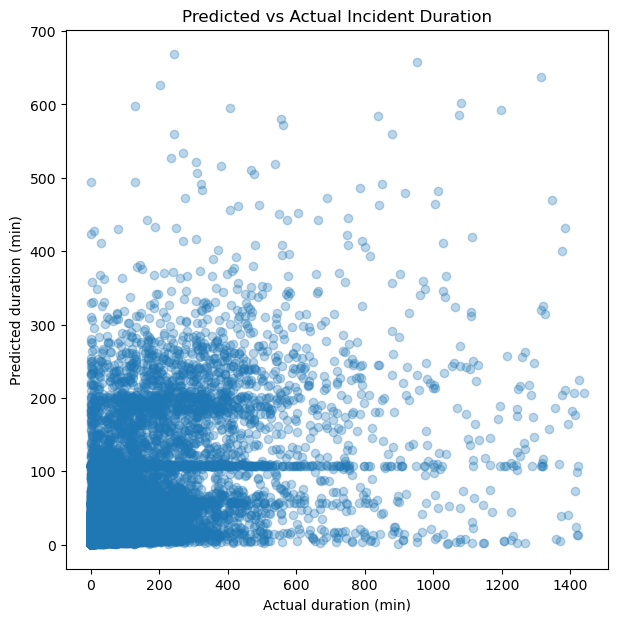

Saved: \\\\Traffic_Incident\outputs\figures\chart_pred_vs_actual_duration.png


In [21]:
plot_df = pred_out[["actual_duration_min", "pred_duration_min"]].dropna().copy()

plt.figure(figsize=(7, 7))
plt.scatter(plot_df["actual_duration_min"], plot_df["pred_duration_min"], alpha=0.3)
plt.xlabel("Actual duration (min)")
plt.ylabel("Predicted duration (min)")
plt.title("Predicted vs Actual Incident Duration")
plt.savefig(OUTPUT_FIG_DIR / "chart_pred_vs_actual_duration.png", dpi=200, bbox_inches="tight")
plt.show()

print("Saved:", OUTPUT_FIG_DIR / "chart_pred_vs_actual_duration.png")

In [ ]:
## 16. Regression Feature Importance Plot

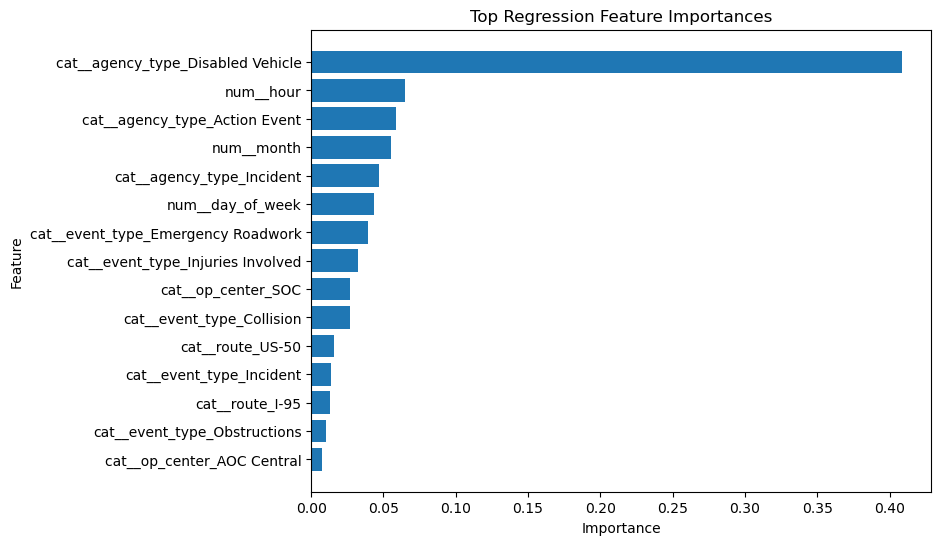

Saved: \\\\Traffic_Incident\outputs\figures\chart_regression_feature_importance.png


In [22]:
top_reg = reg_importance.head(15).sort_values("importance", ascending=True)

plt.figure(figsize=(8, 6))
plt.barh(top_reg["feature"], top_reg["importance"])
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top Regression Feature Importances")
plt.savefig(OUTPUT_FIG_DIR / "chart_regression_feature_importance.png", dpi=200, bbox_inches="tight")
plt.show()

print("Saved:", OUTPUT_FIG_DIR / "chart_regression_feature_importance.png")

In [ ]:
## 17. Classification Feature Importance Plot

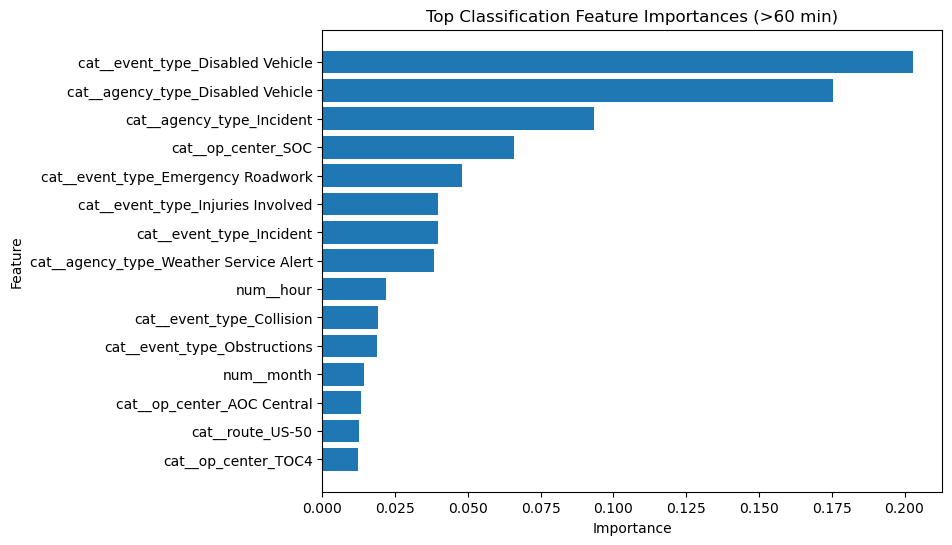

Saved: \\\\Traffic_Incident\outputs\figures\chart_classification_feature_importance.png


In [23]:
top_cls = cls_importance.head(15).sort_values("importance", ascending=True)

plt.figure(figsize=(8, 6))
plt.barh(top_cls["feature"], top_cls["importance"])
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top Classification Feature Importances (>60 min)")
plt.savefig(OUTPUT_FIG_DIR / "chart_classification_feature_importance.png", dpi=200, bbox_inches="tight")
plt.show()

print("Saved:", OUTPUT_FIG_DIR / "chart_classification_feature_importance.png")

In [ ]:
## 18. Confusion Matrix

In [24]:
cm = confusion_matrix(y_test_cls, pred_cls)

cm_df = pd.DataFrame(
    cm,
    index=["Actual_0", "Actual_1"],
    columns=["Pred_0", "Pred_1"]
)

cm_df.to_csv(OUTPUT_TABLE_DIR / "chart_classification_confusion_matrix.csv")

cm_df

,Pred_0,Pred_1
Actual_0,52433,18131
Actual_1,2676,8541


In [ ]:
## 19. Results Summary

The random forest models outperform simple baselines for both regression and classification.

Key findings:

- the regression model improves duration prediction substantially over the median baseline
- the classification model identifies long-duration incidents with strong recall and AUC
- event type, time-of-day, and route context contribute meaningful predictive signal

These results support the use of operational event data for incident duration modeling and traffic management applications.

In [25]:
print("=== Saved tables ===")
for p in sorted(OUTPUT_TABLE_DIR.glob("chart_*")):
    print("-", p.name)

print("\n=== Saved figures ===")
for p in sorted(OUTPUT_FIG_DIR.glob("chart_*")):
    print("-", p.name)

print("\n=== Key results ===")
print("Regression metrics:")
display(reg_metrics_all)

print("Regression metrics in minutes:")
display(rf_reg_duration_metrics)

print("Classification metrics:")
display(cls_metrics_all)

=== Saved tables ===
- chart_classification_confusion_matrix.csv
- chart_classification_feature_importance.csv
- chart_classification_metrics.csv
- chart_duration_quality_summary.csv
- chart_event_type_duration_summary.csv
- chart_events_clean_sample_head.csv
- chart_model_basic_summary.csv
- chart_model_test_predictions.csv
- chart_regression_duration_metrics.csv
- chart_regression_feature_importance.csv
- chart_regression_metrics.csv

=== Saved figures ===
- chart_classification_feature_importance.png
- chart_pred_vs_actual_duration.png
- chart_regression_feature_importance.png

=== Key results ===
Regression metrics:


,model,mae_log,rmse_log,median_ae_log,r2
0,baseline_median,1.213382,1.458422,1.122143,-0.004735
1,random_forest_regressor,0.935944,1.164224,0.822179,0.359737


Regression metrics in minutes:


,model,mae_min,rmse_min,median_ae_min
0,random_forest_regressor,26.391809,76.126339,7.991079


Classification metrics:


,model,accuracy,precision,recall,f1,auc,positive_rate_test,majority_class_predicted
0,baseline_majority,0.862841,0.000000,0.000000,0.000000,NaN,0.137159,0.0
1,random_forest_classifier,0.745577,0.320223,0.761434,0.450843,0.825482,0.137159,NaN
